##  Projet : Prédiction du Risque d'Abandon Scolaire
### Examen - Technologie de l'Intelligence Artificielle

**Objectif** : Construire un modèle de Machine Learning capable de prédire si un étudiant risque d'abandonner ses études, à partir de données académiques et comportementales.

---

### 1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
print(' Bibliothèques importées avec succès')

 Bibliothèques importées avec succès


## 2. Compréhension du Problème

- **Type de problème** : Classification binaire
  - `0` → Pas de risque d'abandon
  - `1` → Risque d'abandon

- **Intérêt** :
  - Améliorer la réussite scolaire
  - Mettre en place des actions préventives ciblées

- **Logique du dataset** : La variable cible est basée sur ≥2 des conditions suivantes :
  - Faible moyenne (< 10/20)
  - Fort absentéisme (> 30%)
  - Faible temps d'étude (< 1h/jour)

### 3. Chargement et Exploration des Données

In [2]:
# Chargement du dataset
df = pd.read_csv('data\student_dropout_dataset.csv')

print(f'Dimensions : {df.shape[0]} étudiants x {df.shape[1]} variables')
print('\n--- Aperçu des données ---')
df.head()

Dimensions : 300 étudiants x 8 variables

--- Aperçu des données ---


,age,gender,average_grade,absenteeism_rate,internet_access,study_time_hours,extra_activities,dropout_risk
0,21,Male,16.27,0.35,Yes,4.1,No,0
1,18,Female,12.30,0.38,No,0.2,No,1
2,22,Male,8.10,0.04,No,3.4,No,0
3,19,Male,13.84,0.25,No,4.8,Yes,0
4,21,Female,14.62,0.47,Yes,0.6,Yes,1


In [3]:
print('--- Informations générales ---')
df.info()
print('\n--- Statistiques descriptives ---')
df.describe()

--- Informations générales ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               300 non-null    int64  
 1   gender            300 non-null    object 
 2   average_grade     300 non-null    float64
 3   absenteeism_rate  300 non-null    float64
 4   internet_access   300 non-null    object 
 5   study_time_hours  300 non-null    float64
 6   extra_activities  300 non-null    object 
 7   dropout_risk      300 non-null    int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 18.9+ KB

--- Statistiques descriptives ---


,age,average_grade,absenteeism_rate,study_time_hours,dropout_risk
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,19.326667,11.600067,0.257633,2.516000,0.243333
std,2.873001,3.705599,0.138460,1.341321,0.429812
min,15.000000,5.030000,0.000000,0.000000,0.000000
25%,17.000000,8.440000,0.147500,1.400000,0.000000
50%,19.000000,11.755000,0.260000,2.600000,0.000000
75%,22.000000,14.640000,0.380000,3.525000,0.000000
max,24.000000,17.960000,0.500000,5.000000,1.000000


In [4]:
# Distribution de la variable cible
print('--- Distribution de dropout_risk ---')
print(df['dropout_risk'].value_counts())
print(f'\nProportion de risque d\'abandon : {df["dropout_risk"].mean()*100:.1f}%')

--- Distribution de dropout_risk ---
dropout_risk
0    227
1     73
Name: count, dtype: int64

Proportion de risque d'abandon : 24.3%


### 4. Prétraitement des Données

In [5]:
# Vérification des valeurs manquantes
print('--- Valeurs manquantes ---')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal valeurs manquantes : {missing.sum()}')

--- Valeurs manquantes ---
age                 0
gender              0
average_grade       0
absenteeism_rate    0
internet_access     0
study_time_hours    0
extra_activities    0
dropout_risk        0
dtype: int64

Total valeurs manquantes : 0


In [6]:
# Vérification des doublons
print(f'Nombre de doublons : {df.duplicated().sum()}')

# Variables catégorielles
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'\nVariables catégorielles : {cat_cols}')
for col in cat_cols:
    print(f'  {col}: {df[col].unique()}')

Nombre de doublons : 0

Variables catégorielles : ['gender', 'internet_access', 'extra_activities']
  gender: ['Male' 'Female']
  internet_access: ['Yes' 'No']
  extra_activities: ['No' 'Yes']


## 5. Analyse Exploratoire des Données (EDA)

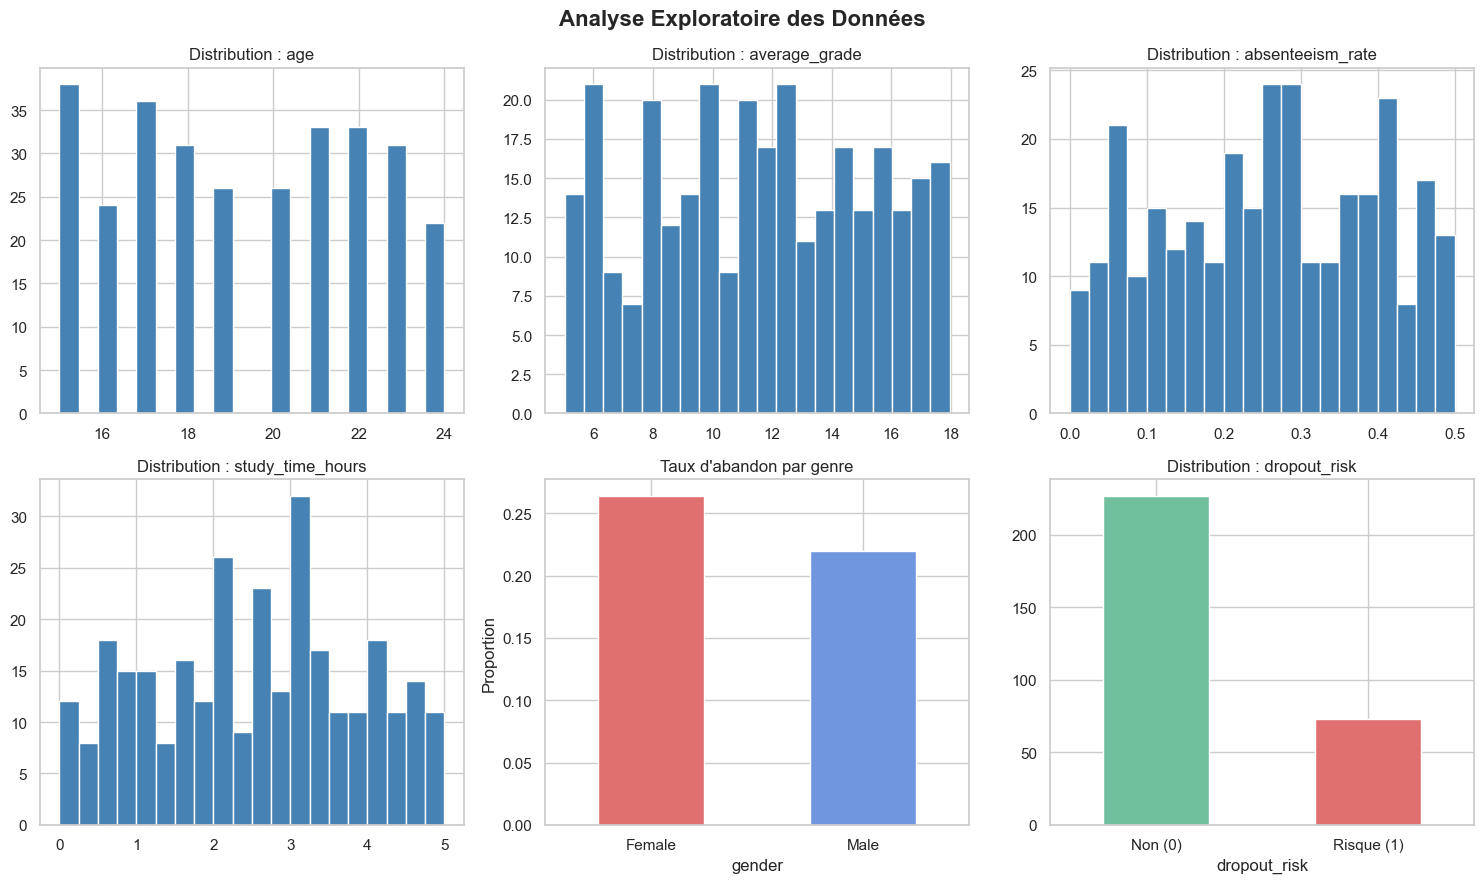

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Analyse Exploratoire des Données', fontsize=16, fontweight='bold')

num_cols = ['age', 'average_grade', 'absenteeism_rate', 'study_time_hours']
for i, col in enumerate(num_cols):
    ax = axes[i//3][i%3]
    df[col].hist(ax=ax, bins=20, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution : {col}')

# Taux d'abandon par genre
df.groupby('gender')['dropout_risk'].mean().plot(
    kind='bar', ax=axes[1][1], color=['#e07070','#7096e0'], edgecolor='white')
axes[1][1].set_title("Taux d'abandon par genre")
axes[1][1].set_ylabel('Proportion')
axes[1][1].tick_params(axis='x', rotation=0)

# Distribution variable cible
df['dropout_risk'].value_counts().plot(
    kind='bar', ax=axes[1][2], color=['#70c09e','#e07070'], edgecolor='white')
axes[1][2].set_title('Distribution : dropout_risk')
axes[1][2].set_xticklabels(['Non (0)', 'Risque (1)'], rotation=0)

plt.tight_layout()
plt.show()

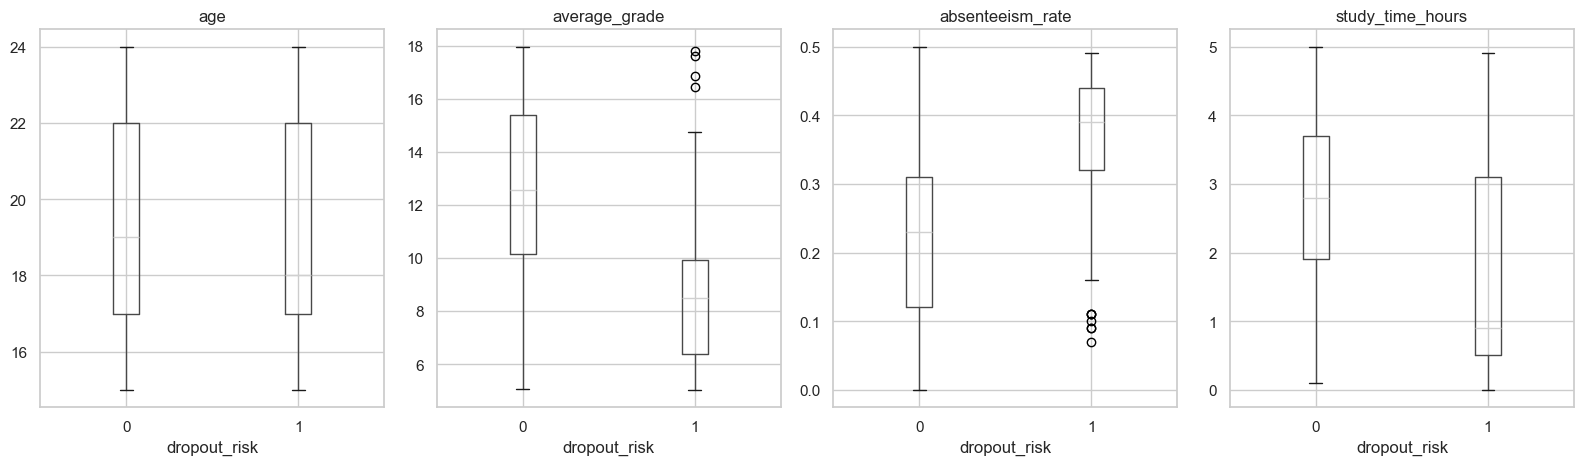

In [8]:
# Boxplots : variables numériques vs dropout_risk
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Variables numériques selon le risque d\'abandon', fontsize=13, fontweight='bold')

for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by='dropout_risk', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('dropout_risk')

plt.suptitle('')
plt.tight_layout()
plt.show()

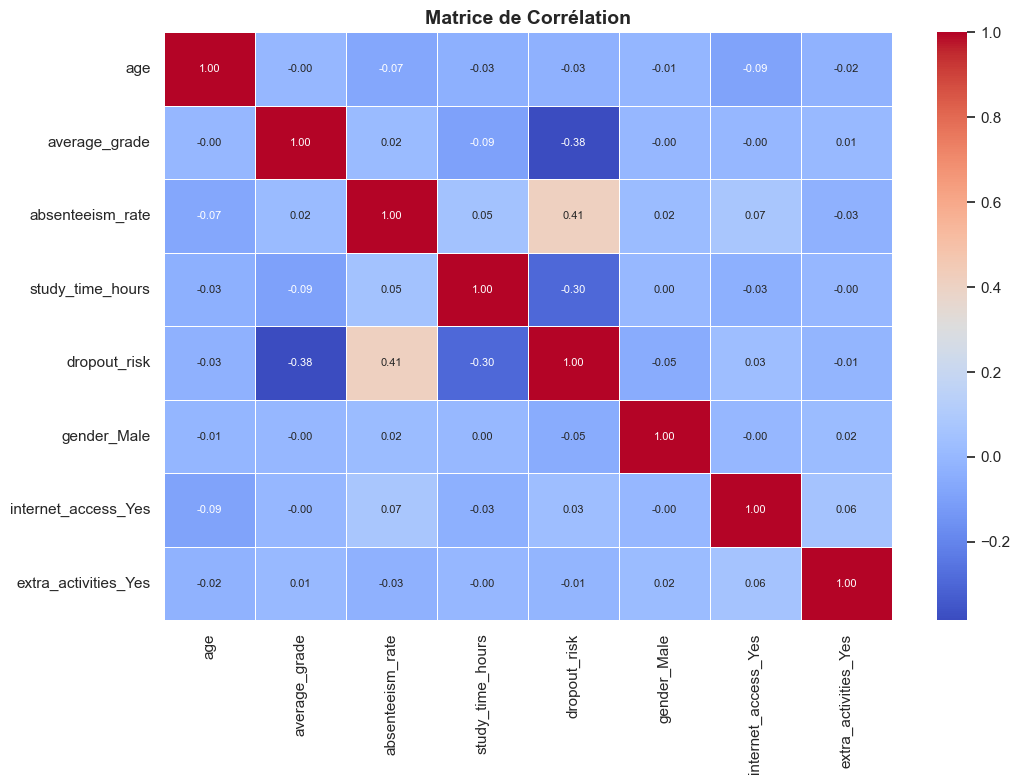

In [9]:
# Matrice de corrélation
df_enc = pd.get_dummies(df, columns=['gender','internet_access','extra_activities'], drop_first=True)

plt.figure(figsize=(11, 8))
sns.heatmap(df_enc.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Matrice de Corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Feature Engineering

In [10]:
df2 = df.copy()

# Nouvelle variable 1 : taux de présence
df2['presence_rate'] = 1 - df2['absenteeism_rate']

# Nouvelle variable 2 : score global composite
df2['global_score'] = (
    (df2['average_grade'] / 20) * 0.5 +
    (1 - df2['absenteeism_rate']) * 0.3 +
    (df2['study_time_hours'] / 5) * 0.2
)

print('Nouvelles variables créées :')
print(df2[['presence_rate', 'global_score']].describe())
print()

# Encodage One-Hot des variables catégorielles
df_model = pd.get_dummies(df2, columns=['gender','internet_access','extra_activities'], drop_first=True)
print(f'Dimensions après feature engineering : {df_model.shape}')
print(f'Colonnes : {list(df_model.columns)}')

Nouvelles variables créées :
       presence_rate  global_score
count     300.000000    300.000000
mean        0.742367      0.613352
std         0.138460      0.109113
min         0.500000      0.331000
25%         0.620000      0.532750
50%         0.740000      0.620000
75%         0.852500      0.689000
max         1.000000      0.880500

Dimensions après feature engineering : (300, 10)
Colonnes : ['age', 'average_grade', 'absenteeism_rate', 'study_time_hours', 'dropout_risk', 'presence_rate', 'global_score', 'gender_Male', 'internet_access_Yes', 'extra_activities_Yes']


### 7. Préparation des Données pour la Modélisation

In [11]:
X = df_model.drop('dropout_risk', axis=1)
y = df_model['dropout_risk']

# Split 80/20 avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation Z-score
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Train : {X_train.shape[0]} échantillons | Test : {X_test.shape[0]} échantillons')
print(f'Distribution train - Dropout: {y_train.value_counts().to_dict()}')
print(f'Distribution test  - Dropout: {y_test.value_counts().to_dict()}')

Train : 240 échantillons | Test : 60 échantillons
Distribution train - Dropout: {0: 182, 1: 58}
Distribution test  - Dropout: {0: 45, 1: 15}


## 8. Entraînement et Évaluation des Modèles

In [12]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(random_state=42, n_estimators=100),
    'SVM':                 SVC(random_state=42, probability=True)
}

results = {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring='f1')
    
    results[name] = {
        'accuracy':   accuracy_score(y_test, y_pred),
        'precision':  precision_score(y_test, y_pred),
        'recall':     recall_score(y_test, y_pred),
        'f1':         f1_score(y_test, y_pred),
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std':  cv_scores.std(),
        'confusion':  confusion_matrix(y_test, y_pred),
        'model':      model
    }
    
    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(f'  Accuracy  : {results[name]["accuracy"]:.4f}')
    print(f'  Precision : {results[name]["precision"]:.4f}')
    print(f'  Recall    : {results[name]["recall"]:.4f}')
    print(f'  F1-Score  : {results[name]["f1"]:.4f}')
    print(f'  CV F1     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'\n  Rapport de classification :')
    print(classification_report(y_test, y_pred, target_names=['Non-abandon','Abandon']))


  Logistic Regression
  Accuracy  : 0.8667
  Precision : 0.7333
  Recall    : 0.7333
  F1-Score  : 0.7333
  CV F1     : 0.7531 ± 0.0572

  Rapport de classification :
              precision    recall  f1-score   support

 Non-abandon       0.91      0.91      0.91        45
     Abandon       0.73      0.73      0.73        15

    accuracy                           0.87        60
   macro avg       0.82      0.82      0.82        60
weighted avg       0.87      0.87      0.87        60


  Random Forest
  Accuracy  : 0.9833
  Precision : 1.0000
  Recall    : 0.9333
  F1-Score  : 0.9655
  CV F1     : 0.9466 ± 0.0352

  Rapport de classification :
              precision    recall  f1-score   support

 Non-abandon       0.98      1.00      0.99        45
     Abandon       1.00      0.93      0.97        15

    accuracy                           0.98        60
   macro avg       0.99      0.97      0.98        60
weighted avg       0.98      0.98      0.98        60


  SVM
  Accurac

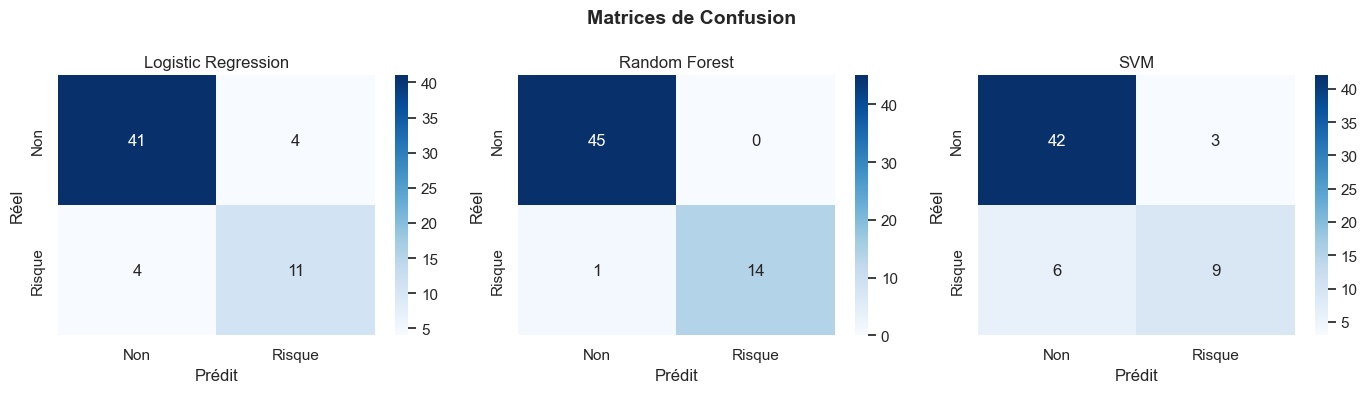

In [13]:
# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Matrices de Confusion', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    sns.heatmap(res['confusion'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non','Risque'], yticklabels=['Non','Risque'])
    ax.set_title(name)
    ax.set_ylabel('Réel')
    ax.set_xlabel('Prédit')

plt.tight_layout()
plt.show()

                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8667     0.7333  0.7333    0.7333
Random Forest          0.9833     1.0000  0.9333    0.9655
SVM                    0.8500     0.7500  0.6000    0.6667


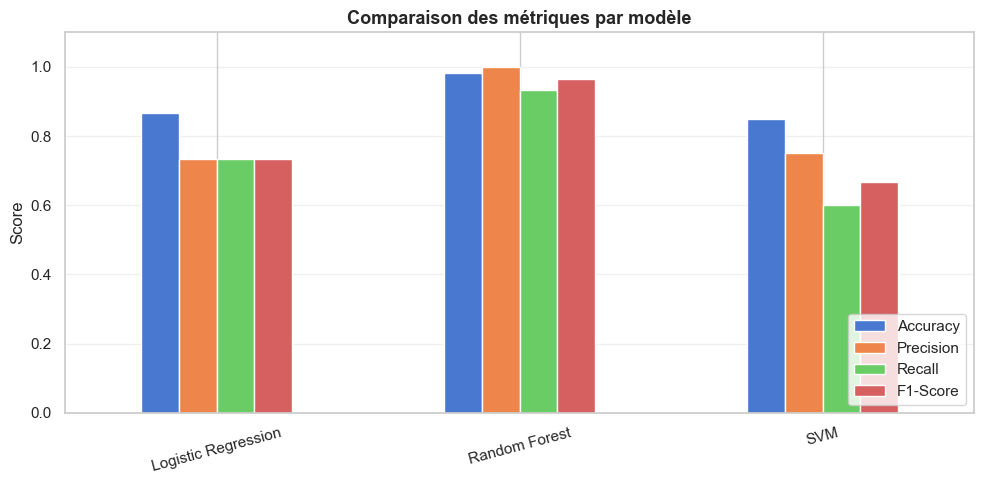

In [14]:
# Comparaison des métriques
metrics_df = pd.DataFrame({
    name: {
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1-Score': res['f1']
    }
    for name, res in results.items()
}).T

print(metrics_df.round(4))

ax = metrics_df.plot(kind='bar', figsize=(10, 5), edgecolor='white')
ax.set_title('Comparaison des métriques par modèle', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.tick_params(axis='x', rotation=15)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Optimisation - Grid Search

In [15]:
# Grid Search sur Random Forest (meilleur modèle)
param_grid = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [None, 5, 10],
    'min_samples_split': [2, 5]
}

gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
gs.fit(X_train_s, y_train)

print(f'Meilleurs hyperparamètres : {gs.best_params_}')
print(f'Meilleur score CV (F1)    : {gs.best_score_:.4f}')

# Évaluation du modèle optimisé
y_pred_best = gs.best_estimator_.predict(X_test_s)
print(f'\n--- Modèle Optimisé (Random Forest) ---')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'Precision : {precision_score(y_test, y_pred_best):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_best):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_best):.4f}')

Meilleurs hyperparamètres : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur score CV (F1)    : 0.9546

--- Modèle Optimisé (Random Forest) ---
Accuracy  : 0.9833
Precision : 1.0000
Recall    : 0.9333
F1-Score  : 0.9655


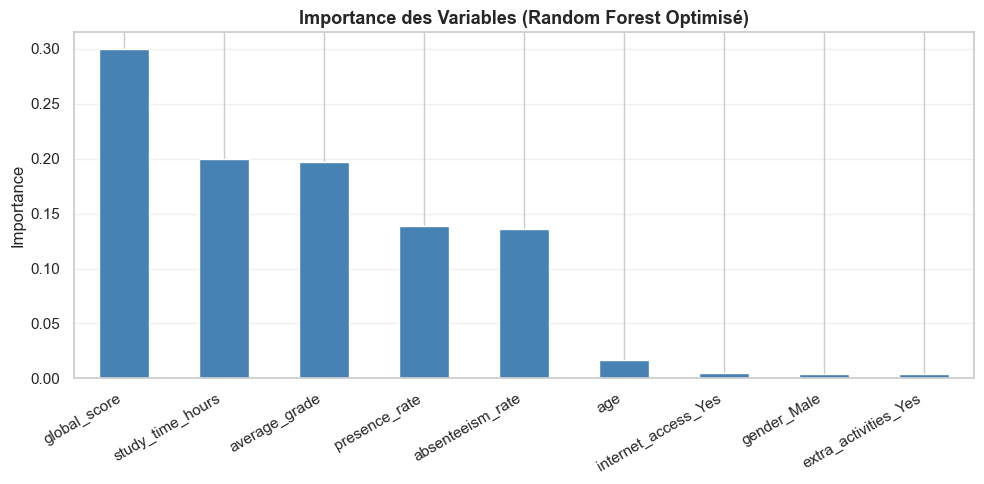


Top 5 variables les plus importantes :
global_score        0.300100
study_time_hours    0.199313
average_grade       0.196646
presence_rate       0.138494
absenteeism_rate    0.135757
dtype: float64


In [16]:
# Importance des variables
rf_best = gs.best_estimator_
feat_imp = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Importance des Variables (Random Forest Optimisé)', fontsize=13, fontweight='bold')
plt.ylabel('Importance')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop 5 variables les plus importantes :')
print(feat_imp.head())

## 10. Prédiction sur un Nouvel Étudiant

In [17]:
def predict_student(age, gender, average_grade, absenteeism_rate,
                    internet_access, study_time_hours, extra_activities):
    """
    Prédit le risque d'abandon d'un étudiant.
    """
    # Créer un DataFrame pour le nouvel étudiant
    student = pd.DataFrame([{
        'age': age,
        'gender': gender,
        'average_grade': average_grade,
        'absenteeism_rate': absenteeism_rate,
        'internet_access': internet_access,
        'study_time_hours': study_time_hours,
        'extra_activities': extra_activities
    }])
    
    # Feature engineering
    student['presence_rate'] = 1 - student['absenteeism_rate']
    student['global_score'] = (
        (student['average_grade'] / 20) * 0.5 +
        (1 - student['absenteeism_rate']) * 0.3 +
        (student['study_time_hours'] / 5) * 0.2
    )
    
    # Encodage
    student = pd.get_dummies(student, columns=['gender','internet_access','extra_activities'], drop_first=True)
    
    # Aligner les colonnes avec celles d'entraînement
    for col in X.columns:
        if col not in student.columns:
            student[col] = 0
    student = student[X.columns]
    
    # Normalisation
    student_s = scaler.transform(student)
    
    # Prédiction
    pred = rf_best.predict(student_s)[0]
    proba = rf_best.predict_proba(student_s)[0][1]
    
    return pred, proba


# Test sur des exemples
exemples = [
    (17, 'Male',   7.5,  0.40, 'No',  0.5, 'No'),   # Profil à risque
    (20, 'Female', 15.0, 0.05, 'Yes', 3.5, 'Yes'),  # Profil non à risque
    (19, 'Male',   9.0,  0.35, 'No',  0.8, 'No'),   # Borderline
]

print('=== Prédictions sur de nouveaux étudiants ===\n')
for i, ex in enumerate(exemples, 1):
    pred, proba = predict_student(*ex)
    statut = '  RISQUE D\'ABANDON' if pred == 1 else '  PAS DE RISQUE'
    print(f'Étudiant {i}: {statut} (probabilité = {proba:.1%})')

=== Prédictions sur de nouveaux étudiants ===

Étudiant 1:   RISQUE D'ABANDON (probabilité = 100.0%)
Étudiant 2:   PAS DE RISQUE (probabilité = 0.0%)
Étudiant 3:   RISQUE D'ABANDON (probabilité = 98.0%)


## 11. Sauvegarde du Meilleur Modèle

In [18]:
import pickle
import os

# Créer le dossier de sauvegarde s'il n'existe pas
os.makedirs('models', exist_ok=True)

# ── Sauvegarde du meilleur modèle (Random Forest optimisé) ──
with open('models/random_forest_best.pkl', 'wb') as f:
    pickle.dump(rf_best, f)
print(' Modèle Random Forest sauvegardé → models/random_forest_best.pkl')

# ── Sauvegarde du scaler (indispensable pour les nouvelles prédictions) ──
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(' Scaler sauvegardé              → models/scaler.pkl')

# ── Sauvegarde de la liste des colonnes (pour aligner les futures données) ──
with open('models/feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)
print('Colonnes sauvegardées          → models/feature_columns.pkl')

print(f'\n Fichiers sauvegardés dans le dossier models/ :')
for fname in os.listdir('models'):
    size = os.path.getsize(f'models/{fname}')
    print(f'   {fname:35s}  ({size/1024:.1f} Ko)')

 Modèle Random Forest sauvegardé → models/random_forest_best.pkl
 Scaler sauvegardé              → models/scaler.pkl
Colonnes sauvegardées          → models/feature_columns.pkl

 Fichiers sauvegardés dans le dossier models/ :
   feature_columns.pkl                  (0.2 Ko)
   logistic_regression.pkl              (0.8 Ko)
   random_forest.pkl                    (495.7 Ko)
   random_forest_best.pkl               (495.7 Ko)
   scaler.pkl                           (0.9 Ko)
   svm.pkl                              (9.8 Ko)


In [19]:
# ── Vérification : rechargement et test du modèle sauvegardé ──
with open('models/random_forest_best.pkl', 'rb') as f:
    model_charge = pickle.load(f)

with open('models/scaler.pkl', 'rb') as f:
    scaler_charge = pickle.load(f)

with open('models/feature_columns.pkl', 'rb') as f:
    colonnes_chargees = pickle.load(f)

# Prédiction de vérification sur le jeu de test
y_pred_check = model_charge.predict(scaler_charge.transform(X_test[colonnes_chargees]))
acc_check = accuracy_score(y_test, y_pred_check)

print(' Vérification après rechargement :')
print(f'   Accuracy : {acc_check:.4f}  → {" Identique au modèle original" if abs(acc_check - 0.9833) < 0.001 else " Différence détectée"}')
print(f'   Colonnes : {colonnes_chargees}')

 Vérification après rechargement :
   Accuracy : 0.9833  →  Identique au modèle original
   Colonnes : ['age', 'average_grade', 'absenteeism_rate', 'study_time_hours', 'presence_rate', 'global_score', 'gender_Male', 'internet_access_Yes', 'extra_activities_Yes']


## 12. Résumé des Résultats

| Modèle | Accuracy | Precision | Recall | F1-Score |
|--------|----------|-----------|--------|----------|
| Logistic Regression | 0.867 | 0.733 | 0.733 | 0.733 |
| **Random Forest** | **0.983** | **1.000** | **0.933** | **0.966** |
| SVM | 0.850 | 0.750 | 0.600 | 0.667 |

### Conclusions
- Le **Random Forest** est le meilleur modèle avec un F1-Score de **0.966** et une Accuracy de **0.983**.
- Les variables les plus importantes sont : `average_grade`, `absenteeism_rate`, `global_score`, `study_time_hours`.
- Le Grid Search confirme les hyperparamètres optimaux : `n_estimators=200`, `max_depth=None`, `min_samples_split=2`.